In [1]:
import torch
from torch.utils.data import Dataset,  DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import torchvision
from torchvision import datasets, models, transforms
from torchvision.transforms import ToTensor, Lambda



import os
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
from tempfile import TemporaryDirectory
matplotlib.use('Agg')
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
import torch
print(torch.cuda.is_available())

True


# Data augmentation and normalization for training
Just normalization for validation

In [4]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'data/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


# Image visualization

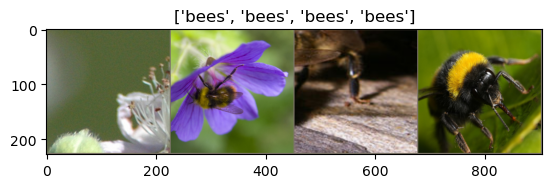

In [6]:
%matplotlib inline
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated
    plt.show()


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])



# Training the model

In [8]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [9]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

# ConvNet as fixed feature extractor

In [11]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

## Train and evaluate

In [31]:
%%time
model_conv = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6432 Acc: 0.6762
val Loss: 0.4879 Acc: 0.7451

Epoch 1/24
----------
train Loss: 0.5058 Acc: 0.7951
val Loss: 0.2009 Acc: 0.9477

Epoch 2/24
----------
train Loss: 0.3236 Acc: 0.8730
val Loss: 0.1520 Acc: 0.9673

Epoch 3/24
----------
train Loss: 0.5660 Acc: 0.7541
val Loss: 0.4717 Acc: 0.8170

Epoch 4/24
----------
train Loss: 0.6769 Acc: 0.7377
val Loss: 0.1556 Acc: 0.9608

Epoch 5/24
----------
train Loss: 0.4774 Acc: 0.7910
val Loss: 0.2105 Acc: 0.9412

Epoch 6/24
----------
train Loss: 0.4117 Acc: 0.8279
val Loss: 0.1839 Acc: 0.9477

Epoch 7/24
----------
train Loss: 0.3507 Acc: 0.8566
val Loss: 0.1637 Acc: 0.9412

Epoch 8/24
----------
train Loss: 0.3302 Acc: 0.8566
val Loss: 0.1858 Acc: 0.9542

Epoch 9/24
----------
train Loss: 0.3728 Acc: 0.8156
val Loss: 0.2092 Acc: 0.9412

Epoch 10/24
----------
train Loss: 0.3965 Acc: 0.8279
val Loss: 0.1788 Acc: 0.9412

Epoch 11/24
----------
train Loss: 0.3310 Acc: 0.8484
val Loss: 0.1965 Acc: 0.9477

Ep

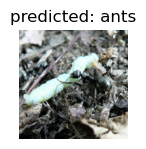

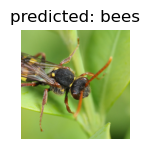

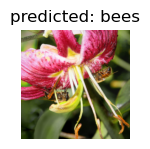

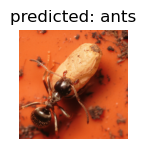

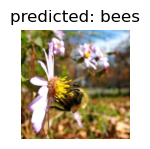

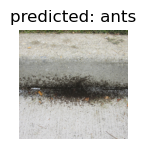

CPU times: total: 359 ms
Wall time: 2.91 s


In [32]:
%%time
visualize_model(model_conv)

# Confusion matrix

In [34]:
def get_all_preds_and_labels(dataloader, model, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            preds = model(X).argmax(1).cpu()  # get predicted classes
            all_preds.extend(preds)
            all_labels.extend(y)

    return torch.tensor(all_preds), torch.tensor(all_labels)

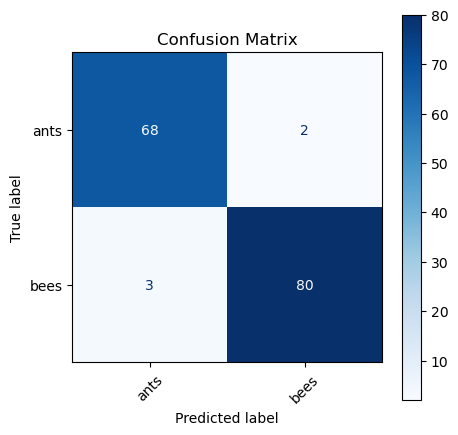

In [35]:
# Get predictions
preds, labels = get_all_preds_and_labels(dataloaders['val'], model_conv, device)

# Compute confusion matrix
cm = confusion_matrix(labels, preds)
%matplotlib inline
# Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title("Confusion Matrix")
plt.show()